In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report, 
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import joblib

BASE_DIR = Path().resolve().parent

In [10]:
import re

X.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X.columns]
print("Column names cleaned successfully")
print(f"Sample columns: {list(X.columns[:5])}")

Column names cleaned successfully
Sample columns: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']


In [11]:
processed_path = BASE_DIR / "data" / "processed" / "processed_train.csv"
data = pd.read_csv(processed_path)

X = data.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = data['TARGET']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Default rate: {y.mean()*100:.2f}%")

Features shape: (307511, 193)
Target shape: (307511,)
Default rate: 8.07%


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training default rate: {y_train.mean()*100:.2f}%")
print(f"Test default rate: {y_test.mean()*100:.2f}%")

Training set: (246008, 193)
Test set: (61503, 193)
Training default rate: 8.07%
Test default rate: 8.07%


In [15]:
import re

def clean_column_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in df.columns]
    return df


smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)


X_train_balanced = pd.DataFrame(X_train_balanced, columns=X_train.columns)
X_test = pd.DataFrame(X_test, columns=X_train.columns)


X_train_balanced = clean_column_names(X_train_balanced)
X_test = clean_column_names(X_test)

print("Column names cleaned successfully")
print(f"Balanced training shape: {X_train_balanced.shape}")

Column names cleaned successfully
Balanced training shape: (452296, 193)


In [16]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, 
                              eval_metric='auc', verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_balanced, y_train_balanced)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    results[name] = {'model': model, 'auc': auc, 'proba': y_pred_proba}
    print(f"  ROC-AUC: {auc:.4f}")
    

Training Logistic Regression...


  ROC-AUC: 0.6169
Training Random Forest...
  ROC-AUC: 0.7025
Training XGBoost...
  ROC-AUC: 0.7522
Training LightGBM...
  ROC-AUC: 0.7513


              Model  ROC-AUC
            XGBoost 0.752204
           LightGBM 0.751324
      Random Forest 0.702453
Logistic Regression 0.616911


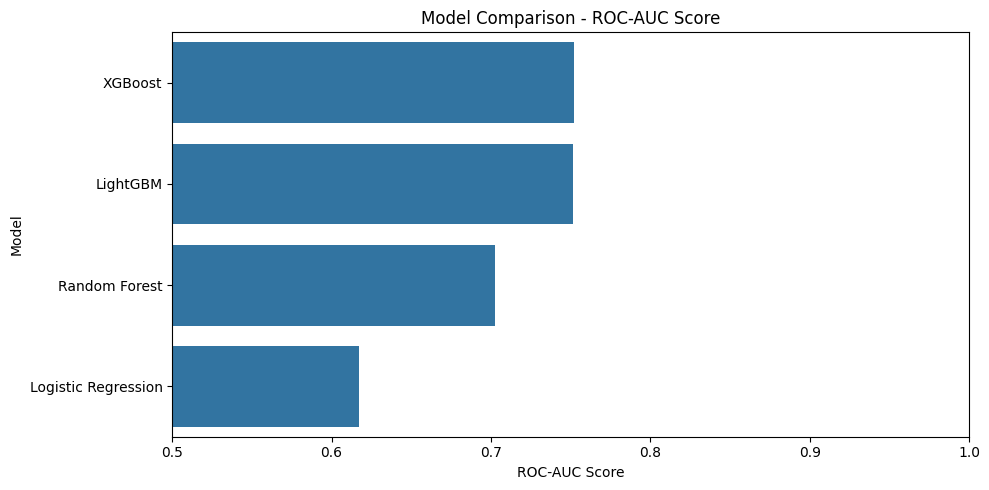

In [17]:
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'ROC-AUC': [results[m]['auc'] for m in results]
}).sort_values('ROC-AUC', ascending=False)

print(results_df.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(x='ROC-AUC', y='Model', data=results_df)
plt.title('Model Comparison - ROC-AUC Score')
plt.xlabel('ROC-AUC Score')
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png')
plt.show()

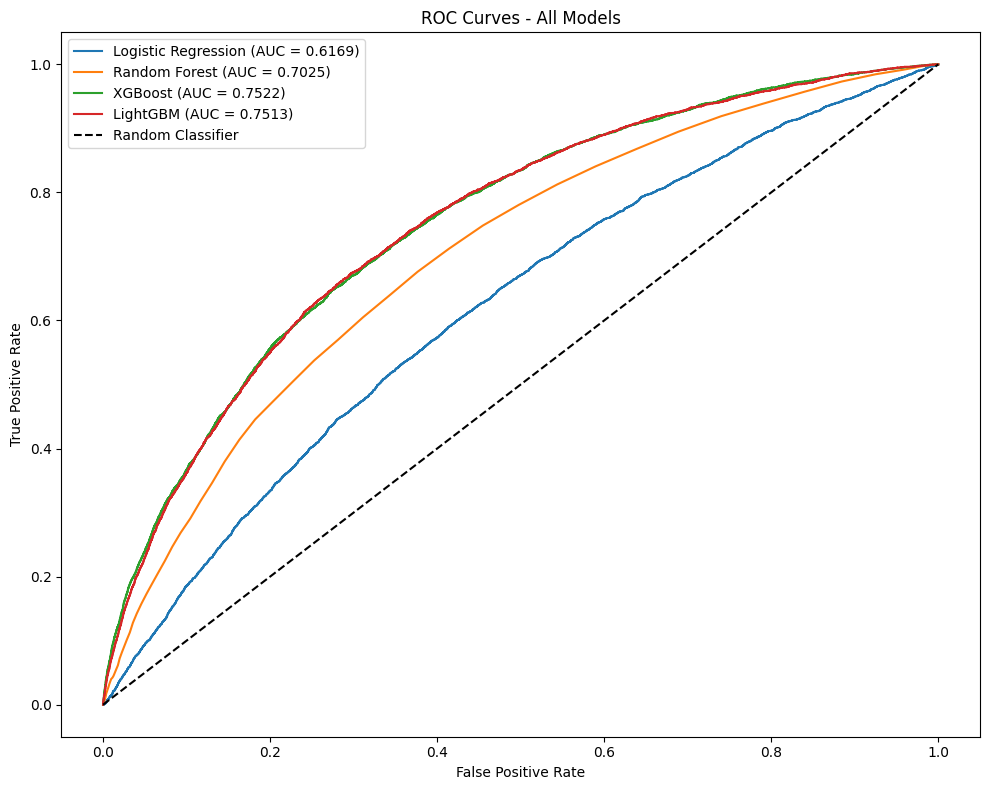

In [18]:
plt.figure(figsize=(10, 8))

for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {result['auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/roc_curves.png')
plt.show()

In [19]:
best_model_name = results_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
best_proba = results[best_model_name]['proba']
best_pred = (best_proba >= 0.5).astype(int)

print(f"Best Model: {best_model_name}")
print(f"ROC-AUC: {results_df.iloc[0]['ROC-AUC']:.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, best_pred, 
                            target_names=['Repaid', 'Defaulted']))

Best Model: XGBoost
ROC-AUC: 0.7522

Classification Report:

              precision    recall  f1-score   support

      Repaid       0.92      1.00      0.96     56538
   Defaulted       0.47      0.05      0.09      4965

    accuracy                           0.92     61503
   macro avg       0.70      0.52      0.52     61503
weighted avg       0.89      0.92      0.89     61503



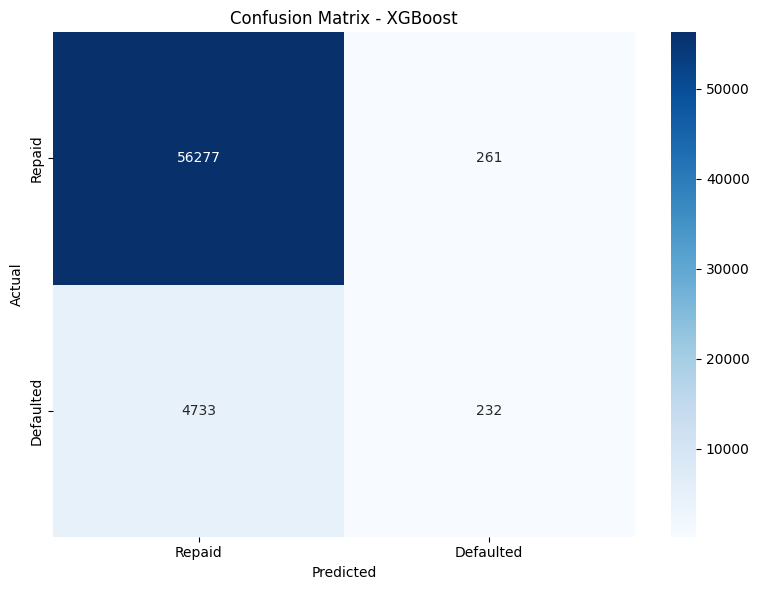

In [20]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Repaid', 'Defaulted'],
            yticklabels=['Repaid', 'Defaulted'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png')
plt.show()

In [21]:

best_auc = results_df.iloc[0]['ROC-AUC']
gini = 2 * best_auc - 1
print(f"Gini Coefficient: {gini:.4f}")


from scipy.stats import ks_2samp
defaulters_scores = best_proba[y_test == 1]
non_defaulters_scores = best_proba[y_test == 0]
ks_stat, ks_pvalue = ks_2samp(defaulters_scores, non_defaulters_scores)
print(f"KS Statistic: {ks_stat:.4f}")
print(f"KS P-value: {ks_pvalue:.6f}")


print(f"\nModel Performance Summary:")
print(f"  ROC-AUC : {best_auc:.4f} {'✓ Good' if best_auc > 0.75 else '✗ Needs improvement'}")
print(f"  Gini    : {gini:.4f} {'✓ Good' if gini > 0.5 else '✗ Needs improvement'}")
print(f"  KS Stat : {ks_stat:.4f} {'✓ Good' if ks_stat > 0.3 else '✗ Needs improvement'}")

Gini Coefficient: 0.5044
KS Statistic: 0.3733
KS P-value: 0.000000

Model Performance Summary:
  ROC-AUC : 0.7522 ✓ Good
  Gini    : 0.5044 ✓ Good
  KS Stat : 0.3733 ✓ Good


In [23]:
models_path = BASE_DIR / "models"
models_path.mkdir(exist_ok=True)

joblib.dump(best_model, models_path / "best_model.pkl")
print(f"Model saved: {best_model_name}")
print(f"Location: {models_path / 'best_model.pkl'}")


results_df.to_csv(models_path / "model_results.csv", index=False)
print("Results saved!")

Model saved: XGBoost
Location: C:\Users\ADMIN\credit-intelligence\models\best_model.pkl
Results saved!
